In [4]:
import pandas as pd
import numpy as np
import joblib
from collections import Counter
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    f1_score
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns


RANDOM_STATE = 42
TEST_SIZE = 0.2
TARGET_COL = "HeartDisease"


# Görsel ayarlar
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8,5)


In [5]:
# Veri
df = pd.read_csv("heart_2020_cleaned.csv")

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  object 
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  object 
 3   AlcoholDrinking   319795 non-null  object 
 4   Stroke            319795 non-null  object 
 5   PhysicalHealth    319795 non-null  float64
 6   MentalHealth      319795 non-null  float64
 7   DiffWalking       319795 non-null  object 
 8   Sex               319795 non-null  object 
 9   AgeCategory       319795 non-null  object 
 10  Race              319795 non-null  object 
 11  Diabetic          319795 non-null  object 
 12  PhysicalActivity  319795 non-null  object 
 13  GenHealth         319795 non-null  object 
 14  SleepTime         319795 non-null  float64
 15  Asthma            319795 non-null  object 
 16  KidneyDisease     31

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


In [6]:
# Remove Race
if "Race" in df.columns:
    df = df.drop(columns=["Race"])
    print("Column 'Race' removed from dataset.")

Column 'Race' removed from dataset.


In [7]:
# Convert Yes/No → 1/0 automatically
if df[TARGET_COL].dtype == "object":
    df[TARGET_COL] = df[TARGET_COL].map(
        lambda x: 1 if str(x).lower() in ("yes", "y", "1", "true") else 0
    )

In [8]:
y = df[TARGET_COL]
X = df.drop(columns=[TARGET_COL])

In [9]:
# 2. Detect column types
cat_cols = [c for c in X.columns if X[c].dtype == "object"]
num_cols = [c for c in X.columns if c not in cat_cols]

print("Numeric:", num_cols)
print("Categorical:", cat_cols)

Numeric: ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']
Categorical: ['Smoking', 'AlcoholDrinking', 'Stroke', 'DiffWalking', 'Sex', 'AgeCategory', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'Asthma', 'KidneyDisease', 'SkinCancer']


In [10]:
# 3. Preprocessing
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
])

In [11]:
# 4. Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print("Train distribution:", Counter(y_train))
print("Test distribution:", Counter(y_test))

Train distribution: Counter({0: 233938, 1: 21898})
Test distribution: Counter({0: 58484, 1: 5475})


In [12]:
# 5. Handle imbalance
neg, pos = np.sum(y_train == 0), np.sum(y_train == 1)
scale_pos_weight = neg / (pos + 1e-9)
class_weights = {0: 1.0, 1: scale_pos_weight}
print(f"scale_pos_weight = {scale_pos_weight:.3f}")

scale_pos_weight = 10.683


Bu kod, sınıflandırma problemindeki (kalp hastalığınız var/yok) sınıf dengesizliğini gidermeye yardımcı olur

In [13]:
# Pipeline
xgb_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        n_estimators=400,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.9,
        colsample_bytree=0.8,
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=RANDOM_STATE
    ))
])

rf_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=400,
        max_depth=5,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight=class_weights,
        n_jobs=1,
        random_state=RANDOM_STATE
    ))
])

xgb_pipeline.fit(X_train, y_train)
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers cont

In [14]:
def evaluate_model(name, model):
    y_proba = model.predict_proba(X_test)[:, 1]

    roc = roc_auc_score(y_test, y_proba)
    pr = average_precision_score(y_test, y_proba)

    thresholds = np.linspace(0.1, 0.9, 81)
    f1_scores = [
        f1_score(y_test, (y_proba >= t).astype(int))
        for t in thresholds
    ]
    best_t = thresholds[np.argmax(f1_scores)]

    y_pred = (y_proba >= best_t).astype(int)

    print(f"\n===== {name} =====")
    print(f"ROC-AUC : {roc:.4f}")
    print(f"PR-AUC  : {pr:.4f}")
    print(f"Best threshold: {best_t:.2f}")
    print(classification_report(y_test, y_pred))

    return roc, pr

In [15]:
xgb_roc, xgb_pr = evaluate_model("XGBoost", xgb_pipeline)
rf_roc, rf_pr = evaluate_model("Random Forest", rf_pipeline)


===== XGBoost =====
ROC-AUC : 0.8387
PR-AUC  : 0.3470
Best threshold: 0.73
              precision    recall  f1-score   support

           0       0.95      0.90      0.93     58484
           1       0.33      0.49      0.39      5475

    accuracy                           0.87     63959
   macro avg       0.64      0.70      0.66     63959
weighted avg       0.90      0.87      0.88     63959


===== Random Forest =====
ROC-AUC : 0.8060
PR-AUC  : 0.3069
Best threshold: 0.64
              precision    recall  f1-score   support

           0       0.95      0.90      0.92     58484
           1       0.30      0.45      0.36      5475

    accuracy                           0.86     63959
   macro avg       0.62      0.67      0.64     63959
weighted avg       0.89      0.86      0.87     63959



In [16]:
# 10. Pikle formatin dosyasina kaydetme
XGB_MODEL_PATH = "heart_xgb_best.pkl"
RF_MODEL_PATH = "heart_rf_best.pkl"
joblib.dump(xgb_pipeline, XGB_MODEL_PATH)
joblib.dump(rf_pipeline, RF_MODEL_PATH)

print("\nModels saved:")
print(XGB_MODEL_PATH)
print(RF_MODEL_PATH)


Models saved:
heart_xgb_best.pkl
heart_rf_best.pkl


In [17]:
xgb_model = joblib.load("heart_xgb_best.pkl")
rf_model = joblib.load("heart_rf_best.pkl")

print("======XGB_model======")
print(xgb_model)
print("======RF_model======")
print(rf_model)

======XGB_model======
Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['BMI', 'PhysicalHealth',
                                                   'MentalHealth',
                                                   'SleepTime']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['Smoking', 'AlcoholDrinking',
                                                   'Stroke', 'DiffWalking',
                                                   'Sex', 'AgeCategory',
                                                   'Diabetic',
                                                   'PhysicalActivity',
                                                   'GenHealth', 'As

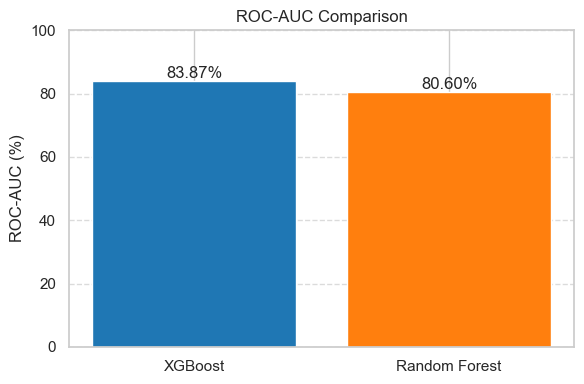

In [18]:
def plot_roc_bar(models):
    names = []
    auc_values = []

    for name, model in models.items():
        y_proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba) * 100

        names.append(name)
        auc_values.append(auc)

    plt.figure(figsize=(6, 4))
    bars = plt.bar(names, auc_values, color=["tab:blue", "tab:orange"] )

    plt.ylabel("ROC-AUC (%)")
    plt.title("ROC-AUC Comparison")

    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"{height:.2f}%",
            ha="center",
            va="bottom"
        )

    plt.ylim(0, 100)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()

plot_roc_bar({
    "XGBoost": xgb_pipeline,
    "Random Forest": rf_pipeline
})

In [19]:
xgboost_model = joblib.load("heart_xgb_best.pkl")
random_forest_model = joblib.load("heart_rf_best.pkl")
df["PredictedRisk_XGBoost"] = xgboost_model.predict_proba(X)[:, 1] * 100
df["PredictedRisk_Random_forest"] = random_forest_model.predict_proba(X)[:, 1] * 100

In [20]:
def plot_bar_with_percent(series, title):
    ax = series.plot(kind="bar", figsize=(6, 4))
    ax.set_ylabel("Tahmin kalp riski oranı (%)")
    ax.set_title(title)

    for p in ax.patches:
        height = p.get_height()
        ax.annotate(
            f"{height:.1f}%",
            (p.get_x() + p.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=10
        )

    plt.tight_layout()
    plt.show()

In [21]:
xgboost_analys_by_phisical_activity = (
    df.groupby("PhysicalActivity")["PredictedRisk_XGBoost"]
    .mean()
)

random_analys_by_phisical_activity = (
    df.groupby("PhysicalActivity")["PredictedRisk_Random_forest"]
    .mean()
)

print("Fiziksel aktiviteye göre kalp hastalığı tahmin riski (XGBoost): ", xgboost_analys_by_phisical_activity)
print("Fiziksel aktiviteye göre kalp hastalığı tahmin riski (Random Forest)", random_analys_by_phisical_activity)

Fiziksel aktiviteye göre kalp hastalığı tahmin riski (XGBoost):  PhysicalActivity
No     47.084633
Yes    30.712505
Name: PredictedRisk_XGBoost, dtype: float32
Fiziksel aktiviteye göre kalp hastalığı tahmin riski (Random Forest) PhysicalActivity
No     51.196863
Yes    39.293753
Name: PredictedRisk_Random_forest, dtype: float64


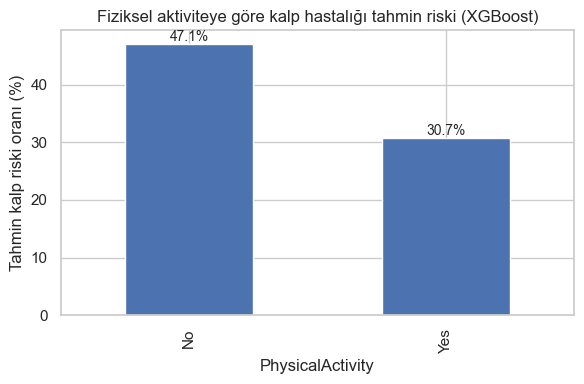

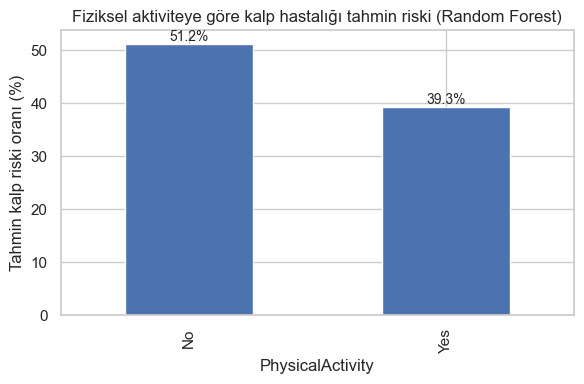

In [22]:
plot_bar_with_percent(
    xgboost_analys_by_phisical_activity,
    "Fiziksel aktiviteye göre kalp hastalığı tahmin riski (XGBoost)"
)

plot_bar_with_percent(
    random_analys_by_phisical_activity,
    "Fiziksel aktiviteye göre kalp hastalığı tahmin riski (Random Forest)"
)


In [24]:
xgboost_stroke_predicted = df.groupby("Stroke")["PredictedRisk_XGBoost"].mean()
random_forest_stroke_predicted = df.groupby("Stroke")["PredictedRisk_Random_forest"].mean()

print("İnme geçmişi olan insanların kalp hastalığı tahmin riski (XGBoost): ", xgboost_stroke_predicted)
print("İnme geçmişi olan insanların kalp hastalığı tahmin riski (Random Forest): ", random_forest_stroke_predicted)

İnme geçmişi olan insanların kalp hastalığı tahmin riski (XGBoost):  Stroke
No     32.574497
Yes    80.688225
Name: PredictedRisk_XGBoost, dtype: float32
İnme geçmişi olan insanların kalp hastalığı tahmin riski (Random Forest):  Stroke
No     40.717284
Yes    73.848263
Name: PredictedRisk_Random_forest, dtype: float64


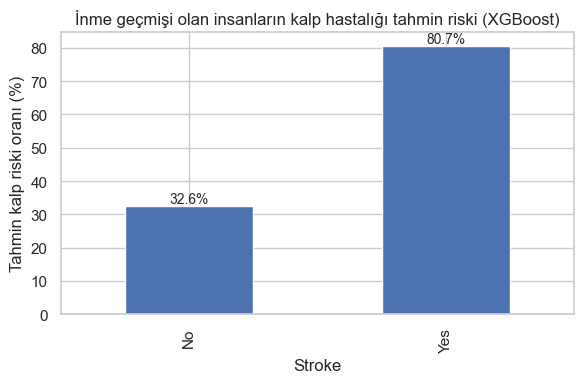

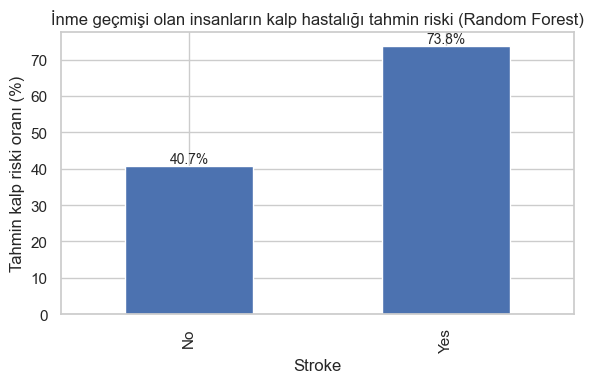

In [25]:
plot_bar_with_percent(
    xgboost_stroke_predicted,
    "İnme geçmişi olan insanların kalp hastalığı tahmin riski (XGBoost)"
)

plot_bar_with_percent(
    random_forest_stroke_predicted,
    "İnme geçmişi olan insanların kalp hastalığı tahmin riski (Random Forest)"
)


In [26]:
xgboost_diffwalking_risk = (
    df.groupby("DiffWalking")["PredictedRisk_XGBoost"]
    .mean()
)

random_forest_diffwalking_risk = (
    df.groupby("DiffWalking")["PredictedRisk_Random_forest"]
    .mean()
)

print("Yürüme zorunluğu olan insanların kalp hastalığı tahmin riski (XGBoost): ", xgboost_diffwalking_risk)
print("Yürüme zorunluğu olan insanların kalp hastalığı tahmin riski (Random Forest): ", random_forest_diffwalking_risk)

Yürüme zorunluğu olan insanların kalp hastalığı tahmin riski (XGBoost):  DiffWalking
No     29.173018
Yes    66.742508
Name: PredictedRisk_XGBoost, dtype: float32
Yürüme zorunluğu olan insanların kalp hastalığı tahmin riski (Random Forest):  DiffWalking
No     37.560135
Yes    69.298442
Name: PredictedRisk_Random_forest, dtype: float64


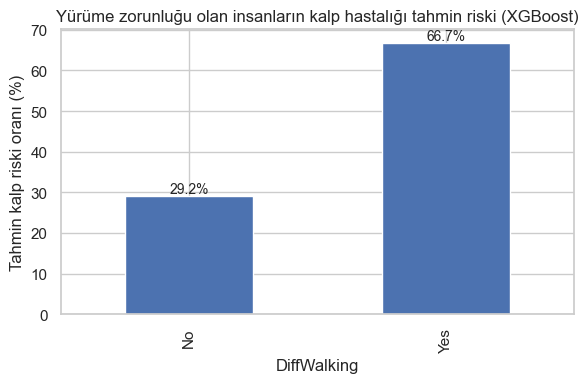

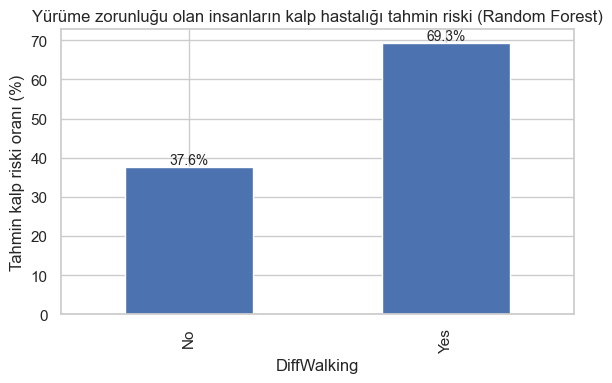

In [27]:
plot_bar_with_percent(
    xgboost_diffwalking_risk,
    "Yürüme zorunluğu olan insanların kalp hastalığı tahmin riski (XGBoost)"
)

plot_bar_with_percent(
    random_forest_diffwalking_risk,
    "Yürüme zorunluğu olan insanların kalp hastalığı tahmin riski (Random Forest)"
)

In [28]:
sleep_group = pd.cut(
    df["SleepTime"],
    bins=[0, 5, 7, 10],
    labels=["<6 saat", "6–7 saat", "7+ saat"]
)

xgboost_sleep_risk = df.groupby(sleep_group)["PredictedRisk_XGBoost"].mean()
random_forest_sleep_risk = df.groupby(sleep_group)["PredictedRisk_Random_forest"].mean()
print("Uyuma saati kalp hasta tahmin riski (XGBoost): ", xgboost_sleep_risk)
print("Uyuma saati kalp hasta tahmin riski: (Random Forest): ", random_forest_sleep_risk)

Uyuma saati kalp hasta tahmin riski (XGBoost):  SleepTime
<6 saat     42.654934
6–7 saat    30.952341
7+ saat     36.443993
Name: PredictedRisk_XGBoost, dtype: float32
Uyuma saati kalp hasta tahmin riski: (Random Forest):  SleepTime
<6 saat     48.368170
6–7 saat    40.284340
7+ saat     42.249079
Name: PredictedRisk_Random_forest, dtype: float64


C:\Users\Casper\AppData\Local\Temp\ipykernel_2300\1275889682.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  xgboost_sleep_risk = df.groupby(sleep_group)["PredictedRisk_XGBoost"].mean()
C:\Users\Casper\AppData\Local\Temp\ipykernel_2300\1275889682.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  random_forest_sleep_risk = df.groupby(sleep_group)["PredictedRisk_Random_forest"].mean()


6 saatten az uyuyan bireylerin riski yaklaşık 2 kat daha fazladır.

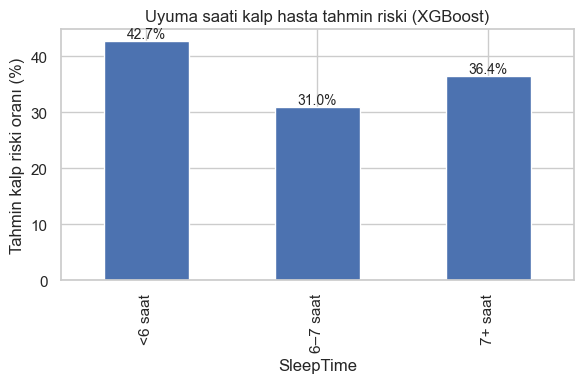

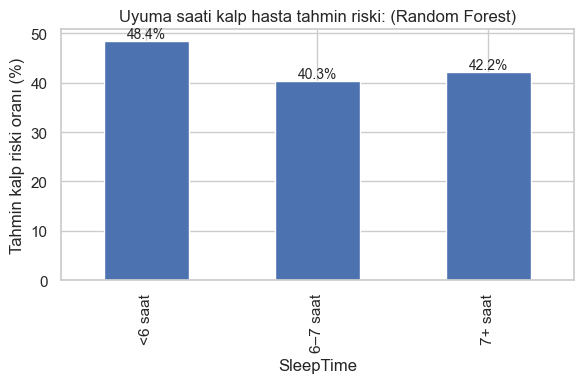

In [29]:
plot_bar_with_percent(
    xgboost_sleep_risk,
    "Uyuma saati kalp hasta tahmin riski (XGBoost)"
)

plot_bar_with_percent(
    random_forest_sleep_risk,
    "Uyuma saati kalp hasta tahmin riski: (Random Forest)"
)

<Axes: xlabel='AgeCategory'>

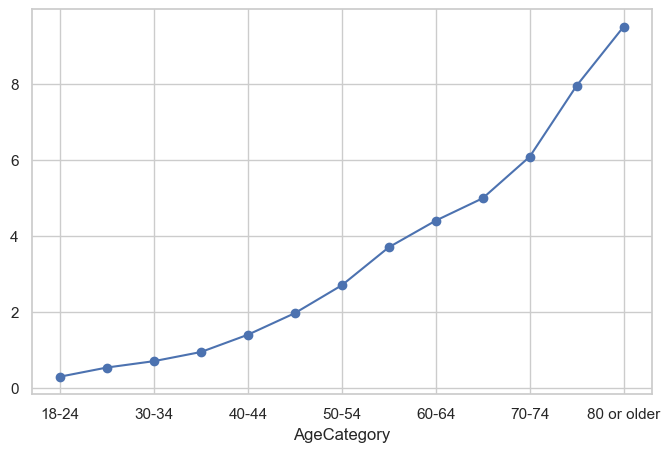

In [111]:
df.groupby("AgeCategory")["Stroke"].apply(
    lambda x: (x == "Yes").mean() * 100
).plot(kind="line", marker="o")